# Purpose
*	Primary goal: Forecast 10-minute ahead (and later hour-ahead) zone power consumption (Zones 1–3) using weather (temperature, humidity, wind) and solar irradiance proxies (general/diffuse flows).
*	Why this matters: Better short-term load forecasts support dispatch planning, demand response, and procurement, while explaining drivers (weather/irradiance) helps operational insight.
*	What we’ll extract:
	1.	Seasonality (intra-day, weekly),
	2.	Weather elasticity (how much load moves with temperature/humidity),
	3.	Lead/lag effects (e.g., irradiance leading demand),
	4.	Baseline models for reference.
*	End state: A comparison of a few models (naïve, linear, tree/boosting) with time-series-safe validation and clear, defensible hyperparameters.

In [1]:
#######################################################
# Sample for MLP Neural Network regression with
#    'TetuanCityPowerConsumption' dataset
#    2025
#######################################################
#
# Learning objectives:
# == split data to train and test sets
# == define MLP regressor
# == fit MLP regressor with different subsets of feature
# == check R squared score
# == check MSE
# == compare R squared for different features
# == compare MSE for different features
########################################################

import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

### Import + load

In [19]:
# I’m importing the core stack I’ll use throughout; this keeps the notebook consistent and reproducible.
import os  # I’ll use this to build robust file paths that work across machines/dirs.
import numpy as np  # I’ll rely on NumPy for numeric ops and array handling.
import pandas as pd  # Pandas will be my backbone for tabular and time-series data wrangling.
import matplotlib.pyplot as plt  # Matplotlib gives me fast plotting without heavy dependencies.
import seaborn as sns  # I’ll use Seaborn for nicer defaults on statistical plots.

# I prefer explicit plotting defaults so figures are readable in HPC/remote notebooks.
plt.rcParams["figure.figsize"] = (10, 4)  # I’m setting a reasonable default size for all plots.
plt.rcParams["axes.grid"] = True  # I turn on a light grid for easier visual estimation.

# I’ll fix a random seed early to make any random splits (later) reproducible.
RNG_SEED = 42  # Single source of truth for randomness.
np.random.seed(RNG_SEED)  # I actually set the seed for NumPy here.

# I like to see more columns when inspecting the DataFrame; this avoids truncated views.
pd.set_option("display.max_columns", 50)  # I increase the column display limit for clarity.
pd.set_option("display.width", 160)  # I widen the console width to reduce line wraps.

In [25]:
# TetuanDF = pd.read_csv('TetuanCityPowerConsumption.csv')

# I point to the dataset; I keep the path in a variable so changing location later is painless.
CSV_PATH = "TetuanCityPowerConsumption.csv"  # I’ll change this if the file is named differently.

# I declare a column rename map to get clean, pythonic names (snake_case, no spaces).
RENAME_MAP = {
    "DateTime": "datetime",  # I want a canonical timestamp column named 'datetime'.
    "Temperature": "temperature",  # I’ll keep units implicit for now; we can add suffixes later.
    "Humidity": "humidity",  # Humidity (%) typically; I’ll verify in EDA.
    "WindSpeed": "wind_speed",  # Wind speed; unit TBD, but name is clean now.
    "GeneralDiffuseFlows": "general_diffuse_flows",  # I normalize spaces to underscores.
    "DiffuseFlows": "diffuse_flows",  # Same here for consistency.
    "Zone1PowerConsumption": "zone1_power",  # I shorten and make these clear targets.
    "Zone2PowerConsumption": "zone2_power",
    "Zone3PowerConsumption": "zone3_power",
}

# I load the CSV; I parse the DateTime column on read so we get proper dtype for time ops.
df_raw = pd.read_csv(
    CSV_PATH,  # I read from the path defined above.
    parse_dates=["DateTime"],  # I ask pandas to parse this column into datetime64 dtype.
    infer_datetime_format=True,  # I let pandas infer the timestamp format for speed.
    dayfirst=False,  # I assume ISO/US ordering unless I detect otherwise in EDA.
    encoding="utf-8"  # I specify utf-8 to avoid implicit encoding surprises.
)  # I now have the raw frame in memory.

# I make a copy before mutating so I can always refer back to the pristine data if needed.
df = df_raw.copy()  # I work on df going forward.

# I standardize the schema right away to avoid downstream name mismatches.
df.rename(columns=RENAME_MAP, inplace=True)  # I apply the rename map defined above.

# I validate that the datetime column exists post-rename; if not, I raise a helpful error.
if "datetime" not in df.columns:  # I guard against schema drift or typos.
    raise ValueError("Expected 'DateTime' column not found or failed to rename to 'datetime'.")

# I sort by time so any rolling/resampling operations behave correctly.
df.sort_values("datetime", inplace=True)  # I ensure time order.
df.reset_index(drop=True, inplace=True)  # I reset the index to keep it tidy.

# I quickly inspect the head to visually confirm the schema looks right.
df.head(3)  # I print a few rows just to sanity-check.

/tmp/ipykernel_52972/2470180044.py:20: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_raw = pd.read_csv(


,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373


In [24]:
df_raw

,DateTime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1PowerConsumption,Zone2PowerConsumption,Zone3PowerConsumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964
...,...,...,...,...,...,...,...,...,...
52411,2017-12-30 23:10:00,7.010,72.4,0.080,0.040,0.096,31160.45627,26857.31820,14780.31212
52412,2017-12-30 23:20:00,6.947,72.6,0.082,0.051,0.093,30430.41825,26124.57809,14428.81152
52413,2017-12-30 23:30:00,6.900,72.8,0.086,0.084,0.074,29590.87452,25277.69254,13806.48259
52414,2017-12-30 23:40:00,6.758,73.0,0.080,0.066,0.089,28958.17490,24692.23688,13512.60504


##### Some integrity checks on missing/duplicates/types/coverage

In [26]:
# I print dtypes to confirm 'datetime' is datetime64 and others are numeric.
print(df.dtypes)  # I expect 'datetime' to be datetime64[ns] and the rest float/int.

# I look for missing values to quantify any data cleaning needed.
na_counts = df.isna().sum()  # I compute count of NA per column.
print("Missing values per column:\n", na_counts)  # I print to decide on imputation vs drop.

# I check for duplicate timestamps because time series should have unique instants per sampling interval.
dupe_dt = df["datetime"].duplicated().sum()  # I count how many duplicated datetime entries exist.
print(f"Duplicate timestamps: {dupe_dt}")  # I’ll resolve if >0.

# I compute basic temporal coverage to know the time range and cadence we actually have.
t_min, t_max = df["datetime"].min(), df["datetime"].max()  # I extract the bounds.
print(f"Time coverage: {t_min} → {t_max}")  # I display the coverage window.

# I infer the median sampling interval to verify it’s ~10 minutes as expected.
median_step = df["datetime"].sort_values().diff().median()  # I compute median delta between rows.
print(f"Median sampling interval: {median_step}")  # I expect 00:10:00; if not, I’ll investigate.

# I set the datetime as index for time-series operations; I keep a separate column if later needed.
df_ts = df.set_index("datetime").sort_index()  # I ensure a proper DatetimeIndex for resampling/rolling.

# I locate missing timestamps compared to an ideal 10-min grid to assess gaps we might impute.
full_index = pd.date_range(start=t_min, end=t_max, freq="10T")  # I create the ideal 10-min grid.
missing_stamps = full_index.difference(df_ts.index)  # I find which timestamps are absent.
print(f"Missing timestamps (count): {len(missing_stamps)}")  # I quantify gaps; may guide imputation later.

datetime                 datetime64[ns]
temperature                     float64
humidity                        float64
wind_speed                      float64
general_diffuse_flows           float64
diffuse_flows                   float64
zone1_power                     float64
zone2_power                     float64
zone3_power                     float64
dtype: object
Missing values per column:
 datetime                 0
temperature              0
humidity                 0
wind_speed               0
general_diffuse_flows    0
diffuse_flows            0
zone1_power              0
zone2_power              0
zone3_power              0
dtype: int64
Duplicate timestamps: 0
Time coverage: 2017-01-01 00:00:00 → 2017-12-30 23:50:00
Median sampling interval: 0 days 00:10:00
Missing timestamps (count): 0


/tmp/ipykernel_52972/662909281.py:24: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=t_min, end=t_max, freq="10T")  # I create the ideal 10-min grid.


##### (OPTIONAL) on google colab

In [ ]:
#
# Load the TetuanCityPowerConsumption data set
#
from google.colab import files
uploaded = files.upload()
# choose the data file 'TetuanCityPowerConsumption' to upload
import io
TetuanDF = pd.read_csv(io.BytesIO(uploaded['TetuanCityPowerConsumption.csv']))
# end of data uploading

In [ ]:
#
# using Pandas extension for viewing data table
#
from google.colab import data_table
data_table.enable_dataframe_formatter()
# -- the following code is to turn off the table view --
# from google.colab import data_table
# data_table.disable_dataframe_formatter()
TetuanDF    # view 'TetuanCityPowerConsumption' dataset

### Explore

#### Descriptives, correlation, daily sample, aggregations

In [27]:
# I compute summary stats to get a feel for ranges, central tendency, and outliers.
desc = df_ts.describe().T  # I transpose for a more readable table (vars as rows).
desc  # I display the stats; I’ll scan min/max for anomalies (e.g., negative humidity).

,count,mean,std,min,25%,50%,75%,max
temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
wind_speed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
general_diffuse_flows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
diffuse_flows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
zone1_power,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
zone2_power,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
zone3_power,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


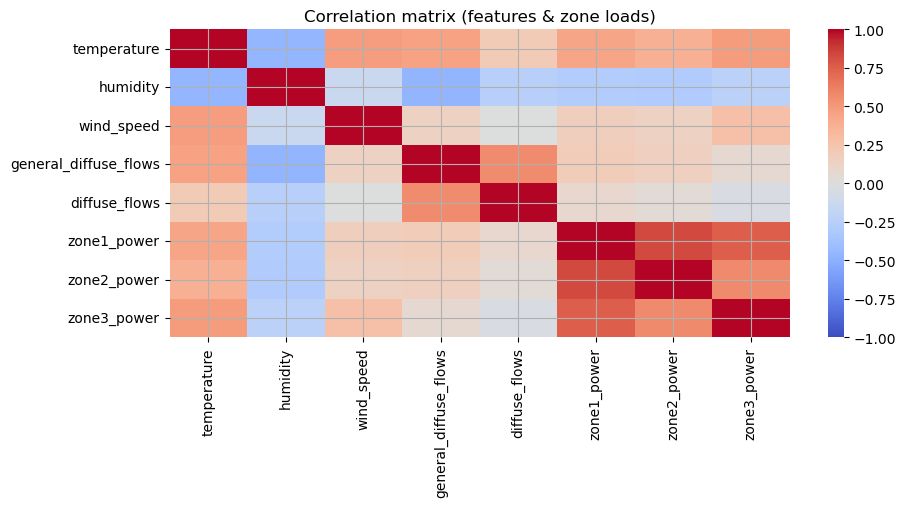

In [28]:

# I look at pairwise correlations to see which drivers move with each zone’s power.
corr = df_ts.corr(numeric_only=True)  # I compute Pearson correlations across numeric columns.
sns.heatmap(corr, vmin=-1, vmax=1, cmap="coolwarm", annot=False)  # I plot a correlation heatmap.
plt.title("Correlation matrix (features & zone loads)")  # I label the figure for context.
plt.show()  # I render the plot now.

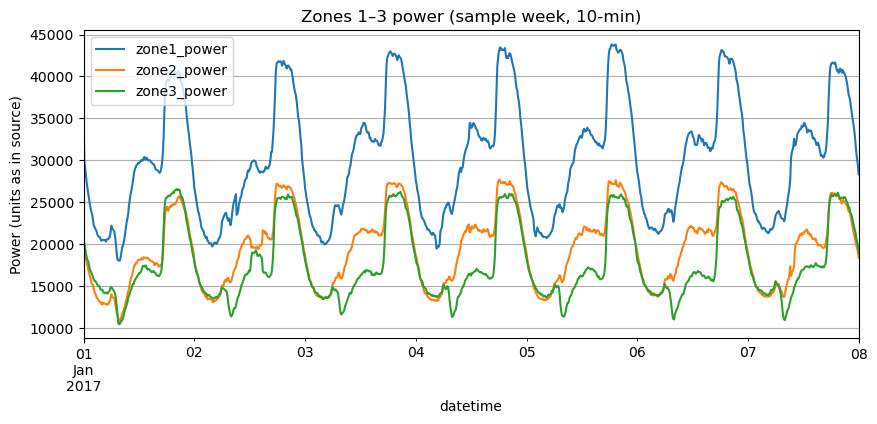

/tmp/ipykernel_52972/3694005716.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_ts.resample("1H").mean()  # I aggregate numeric columns by hourly mean.


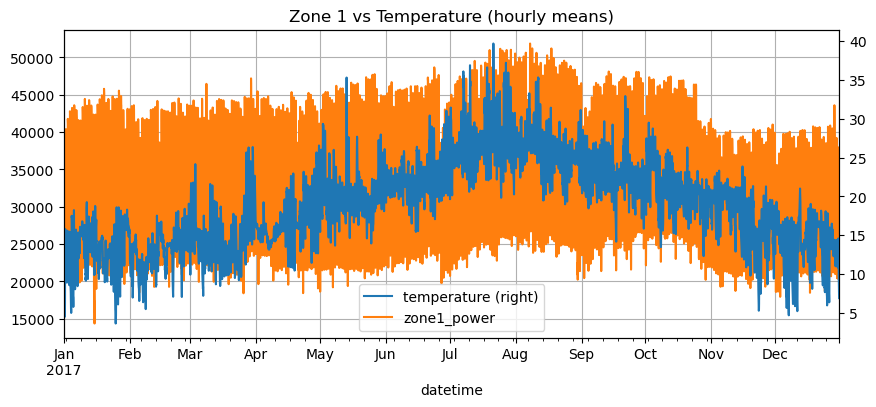

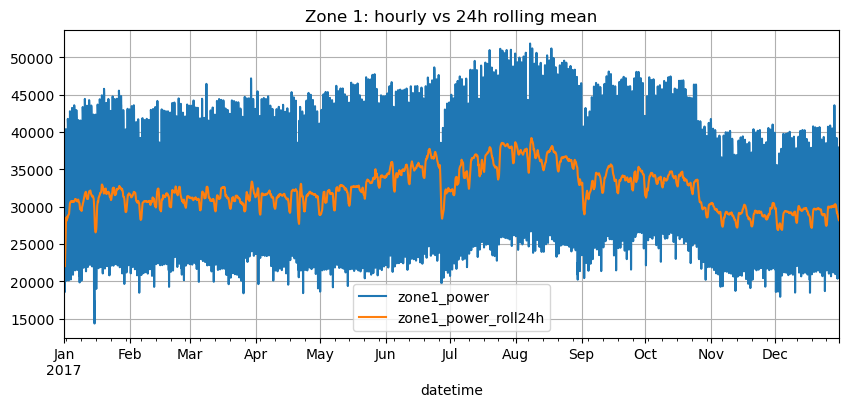

In [29]:
# I pick a representative week to plot at native 10-min granularity for a quick visual read.
sample_start = df_ts.index.min()  # I start at the earliest date available.
sample_end = sample_start + pd.Timedelta(days=7)  # I take one week for a compact view.
df_week = df_ts.loc[sample_start:sample_end]  # I slice the week.

# I plot zone loads over the sample week to visually inspect diurnal patterns and anomalies.
df_week[["zone1_power", "zone2_power", "zone3_power"]].plot()  # I overlay all three zones.
plt.title("Zones 1–3 power (sample week, 10-min)")  # I add a descriptive title.
plt.ylabel("Power (units as in source)")  # I add a unit placeholder; we can refine later.
plt.show()  # I display the chart.

# I resample to hourly means to reduce noise and reveal larger patterns.
df_hourly = df_ts.resample("1H").mean()  # I aggregate numeric columns by hourly mean.

# I plot hourly temperature vs zone1 to eyeball weather–load co-movement.
df_hourly[["temperature", "zone1_power"]].plot(secondary_y="temperature")  # I use twin y-axis for scale mismatch.
plt.title("Zone 1 vs Temperature (hourly means)")  # I label for context.
plt.show()  # I display it to assess alignment.

# I add a simple 24-hour rolling mean on zone1 to highlight daily seasonality.
df_hourly["zone1_power_roll24h"] = df_hourly["zone1_power"].rolling(24, min_periods=1).mean()  # I smooth over 24 hours.
df_hourly[["zone1_power", "zone1_power_roll24h"]].plot()  # I compare raw vs smoothed.
plt.title("Zone 1: hourly vs 24h rolling mean")  # I title to explain the smoothing window.
plt.show()  # I render to visually confirm diurnal pattern.

##### Seasonality & Lag structure

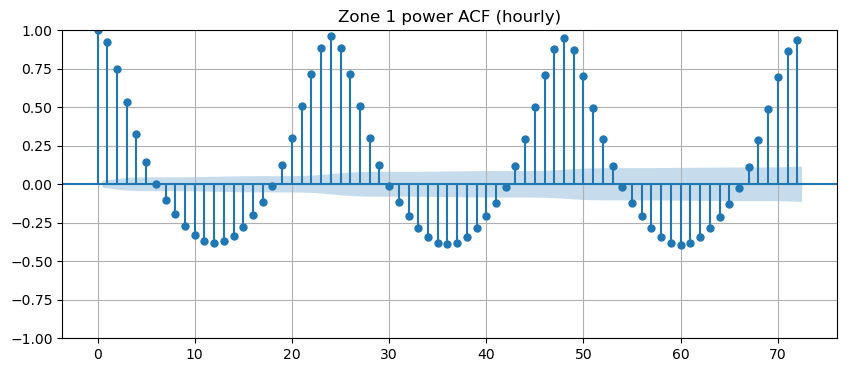

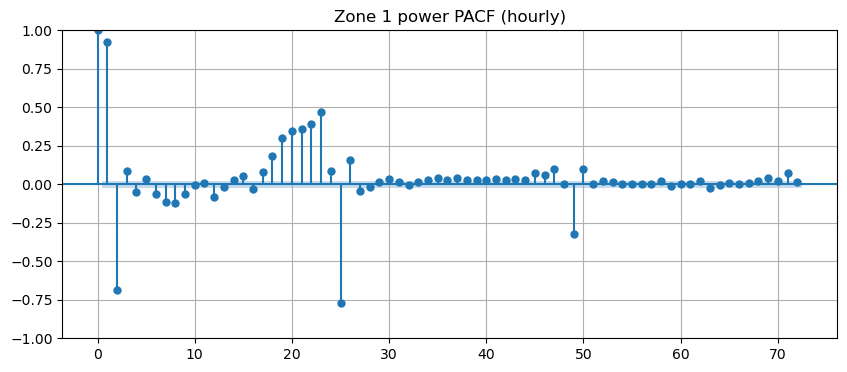

In [30]:
# I import ACF/PACF to understand lag dependence; this informs baseline and AR terms later.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # I bring in autocorrelation plotting.

# I choose Zone 1 hourly to reduce noise and avoid overplotting in ACF/PACF.
z1 = df_hourly["zone1_power"].dropna()  # I pick a clean series for the analysis.

# I plot ACF up to 72 lags (~3 days hourly) to see short-term persistence and daily peaks.
plot_acf(z1, lags=72)  # I look for spikes at 1, 2, … and around 24, 48 for daily seasonality.
plt.title("Zone 1 power ACF (hourly)")  # I add a descriptive title.
plt.show()  # I render the ACF.

# I plot PACF similarly to assess direct lag contributions excluding intermediates.
plot_pacf(z1, lags=72, method="ywm")  # I use Yule-Walker-M estimator for stability.
plt.title("Zone 1 power PACF (hourly)")  # I title accordingly.
plt.show()  # I render the PACF.

In [5]:
#
# Select specific columns
TetuanDF1 = TetuanDF[['Temperature','Humidity','WindSpeed',
                    'GeneralDiffuseFlows','DiffuseFlows']]

# Convert columns to numeric
TetuanDF2 = TetuanDF1.apply(pd.to_numeric, errors='coerce')

# Drop incomplete rows with NAS
TetuanDF3 = TetuanDF2.dropna()

In [7]:
TetuanDF['Zone1PowerConsumption']

0        34055.69620
1        29814.68354
2        29128.10127
3        28228.86076
4        27335.69620
            ...     
52411    31160.45627
52412    30430.41825
52413    29590.87452
52414    28958.17490
52415    28349.80989
Name: Zone1PowerConsumption, Length: 52416, dtype: float64

In [9]:
TetuanDF['Zone2PowerConsumption']

0        16128.87538
1        19375.07599
2        19006.68693
3        18361.09422
4        17872.34043
            ...     
52411    26857.31820
52412    26124.57809
52413    25277.69254
52414    24692.23688
52415    24055.23167
Name: Zone2PowerConsumption, Length: 52416, dtype: float64

In [10]:
TetuanDF['Zone3PowerConsumption']

0        20240.96386
1        20131.08434
2        19668.43373
3        18899.27711
4        18442.40964
            ...     
52411    14780.31212
52412    14428.81152
52413    13806.48259
52414    13512.60504
52415    13345.49820
Name: Zone3PowerConsumption, Length: 52416, dtype: float64

### Feature Engineering

In [31]:
# I prepare calendar/time features that commonly help demand models capture seasonality.
df_ts["hour"] = df_ts.index.hour  # I extract hour-of-day to capture diurnal cycles.
df_ts["dow"] = df_ts.index.dayofweek  # I extract day-of-week to capture weekday/weekend effects.
df_ts["is_weekend"] = (df_ts["dow"] >= 5).astype(int)  # I flag weekends as 1 to capture behavior shifts.

# I create short lags for autoregression; I start with 10min (1 step), 1h (6 steps), 2h (12 steps).
for lag in [1, 6, 12]:  # I loop over a few intuitive lags based on the 10-min cadence.
    df_ts[f"zone1_lag{lag}"] = df_ts["zone1_power"].shift(lag)  # I make lagged zone1 features.
    df_ts[f"zone2_lag{lag}"] = df_ts["zone2_power"].shift(lag)  # I repeat for zone2.
    df_ts[f"zone3_lag{lag}"] = df_ts["zone3_power"].shift(lag)  # And for zone3.

# I consider simple nonlinear transforms for weather to capture curvature (e.g., quadratic temp effects).
df_ts["temperature_sq"] = df_ts["temperature"] ** 2  # I square temperature; cooling/heating loads often curve.
df_ts["humidity_sq"] = df_ts["humidity"] ** 2  # I square humidity as a flexible term.

# I drop initial rows with NaNs due to lag creation so later modeling doesn’t choke.
df_ml = df_ts.dropna().copy()  # I keep a model-ready frame with all features aligned.

# I quickly inspect the engineered columns to confirm they exist as expected.
df_ml.filter(regex="^zone[123]_lag|hour|dow|is_weekend|temperature_sq|humidity_sq").head(3)  # I peek at the new features.

,hour,dow,is_weekend,zone1_lag1,zone2_lag1,zone3_lag1,zone1_lag6,zone2_lag6,zone3_lag6,zone1_lag12,zone2_lag12,zone3_lag12,temperature_sq,humidity_sq
datetime,,,,,,,,,,,,,,
2017-01-01 02:00:00,2,6,1,23544.30380,15213.37386,16395.18072,25998.98734,16993.31307,17945.06024,34055.69620,16128.87538,20240.96386,25.593481,6177.96
2017-01-01 02:10:00,2,6,1,23003.54430,15169.60486,16117.59036,25446.07595,16661.39818,17459.27711,29814.68354,19375.07599,20131.08434,24.681024,6209.44
2017-01-01 02:20:00,2,6,1,22329.11392,14710.03040,15822.65060,24777.72152,16227.35562,17025.54217,29128.10127,19006.68693,19668.43373,24.750625,6225.21


#### Time-aware train and validation split

In [32]:
# I define a chronological split so the model trains on past and validates on future, avoiding leakage.
split_time = df_ml.index.min() + (df_ml.index.max() - df_ml.index.min()) * 0.8  # I choose an 80/20 time split.
print(f"Train/Valid split time: {split_time}")  # I print the boundary to document the split.

# I pick a target; I start with Zone 1 and later repeat for Zones 2/3.
TARGET = "zone1_power"  # I set the target explicitly.

# I define a basic feature set; I exclude the target and keep drivers + lags + calendar features.
feature_cols = [
    "temperature", "humidity", "wind_speed",
    "general_diffuse_flows", "diffuse_flows",
    "hour", "dow", "is_weekend",
    "temperature_sq", "humidity_sq",
    "zone1_lag1", "zone1_lag6", "zone1_lag12",
    "zone2_lag1", "zone2_lag6", "zone2_lag12",
    "zone3_lag1", "zone3_lag6", "zone3_lag12",
]  # I centralize the feature list for reuse and ablation later.

# I split chronologically into train and validation sets.
train_mask = df_ml.index <= split_time  # I mark rows up to the split time for training.
valid_mask = df_ml.index > split_time  # I mark the rest for validation.

X_train = df_ml.loc[train_mask, feature_cols]  # I select training features by mask.
y_train = df_ml.loc[train_mask, TARGET]  # I select the corresponding training target.

X_valid = df_ml.loc[valid_mask, feature_cols]  # I select validation features.
y_valid = df_ml.loc[valid_mask, TARGET]  # I select the validation target.

# I print shapes to confirm the split sizes look reasonable.
print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape)  # I expect ~80/20 temporal split.

Train/Valid split time: 2017-10-19 05:04:00
(41923, 19) (41923,) (10481, 19) (10481,)


##### Baseline forecasts for later comparisions

Baseline (naïve, lag-1) → MAE: 369.584, RMSE: 302459.582


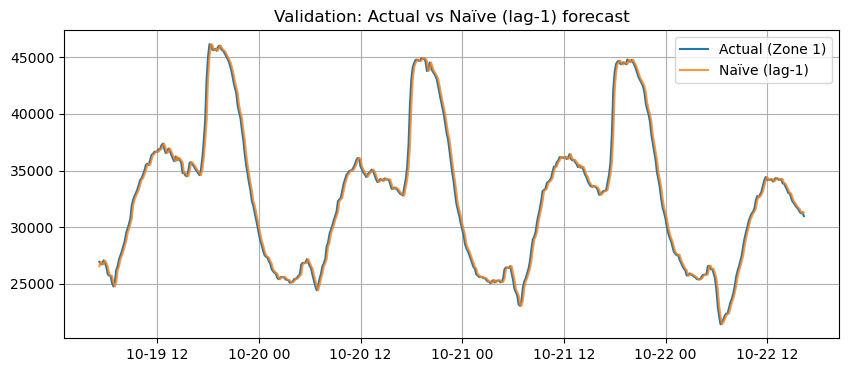

In [34]:
# I create a simple persistence (naïve) baseline: predict that the next value equals the last observed (10-minute lag).
# Note: On the validation set, I use the 1-step lag feature as the naïve predictor.
y_pred_naive = X_valid["zone1_lag1"].copy()  # I take the 10-minute lag as the forecast.

# I compute standard regression metrics to quantify baseline performance.
from sklearn.metrics import mean_absolute_error, mean_squared_error  # I import MAE/MSE.

mae_naive = mean_absolute_error(y_valid, y_pred_naive)  # I compute MAE for the naïve baseline.
rmse_naive = mean_squared_error(y_valid, y_pred_naive)  # I compute RMSE (sqrt MSE).
print(f"Baseline (naïve, lag-1) → MAE: {mae_naive:.3f}, RMSE: {rmse_naive:.3f}")  # I report the baseline scores.

# I plot actual vs naïve predictions on a short validation window to visually inspect fit.
plot_slice = slice(0, min(500, len(y_valid)))  # I bound the plot to avoid overplotting huge series.
y_valid_slice = y_valid.iloc[plot_slice]  # I take a small slice for readability.
y_pred_slice = y_pred_naive.iloc[plot_slice]  # I align the prediction slice.

plt.plot(y_valid_slice.index, y_valid_slice.values, label="Actual (Zone 1)")  # I plot actual load.
plt.plot(y_pred_slice.index, y_pred_slice.values, label="Naïve (lag-1)", alpha=0.8)  # I overlay the baseline forecast.
plt.title("Validation: Actual vs Naïve (lag-1) forecast")  # I title to clarify the baseline shown.
plt.legend()  # I add a legend to distinguish lines.
plt.show()  # I render the plot.

In [6]:
# ----------------------------------------
# Variable Names:
#
# y         == the target
# X_in      == features selected from data
# y_pred    == prediction of y from your model
# X         == the input vector for learning
# X_train   == the input part of training data
# X_test    == the input part of test data
# y_train   == the output part of training data
# y_test    == the output part of test data
# -----------------------------------------
#
# Set the target variable
#
# y = TetuanDF['Zone1PowerConsumption']
#
# y = TetuanDF['Zone2PowerConsumption']
#
y = TetuanDF['Zone3PowerConsumption']
#
# Select feature to use for learning
#
X_in = TetuanDF3
# Convert the data to array with n rows and 5 columns
X = X_in.values.reshape(-1,5)
    # "-1" means to match the data size
    # "5" you have 5 features here

scalar = StandardScaler()
scalar.fit(X)
X_scaled = scalar.transform(X)

# Split train/test sets
# if train_size is not specified, default test/train rate is 0.25/0.75,
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,
                                                    random_state=0,
                                                    train_size=0.75)

## MODEL TRAININGS
Notes on metrics and Cross Validation choices
 * MAE (L1 error): robust to outliers; interprets directly as typical absolute deviation in target units.
 * RMSE (L2 error): penalizes large miss more; highlights catastrophic errors important for operations.
 * TimeSeriesSplit: preserves chronology; avoids information leakage that would inflate scores in random K-fold.
 * Pipelines + scaling: ensure preprocessing learned only from training folds; prevent leakage into validation.
 * Small grids: prioritize informative sweeps over exhaustiveness; keep runtime reasonable on CPU/HPC.

### MLP REGRESSOR

In [36]:
# Import core sklearn tools for pipelines, models, and metrics
from sklearn.pipeline import Pipeline                         # Enforce leak-safe preprocessing + model chaining
from sklearn.preprocessing import StandardScaler              # Standardize features; critical for MLP/KNN stability
from sklearn.neural_network import MLPRegressor               # Use MLP for non-linear function approximation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define helper to fit a pipeline and report metrics on a hold-out set
def fit_and_report(name, model, X_tr, y_tr, X_va, y_va):
    # Build leak-safe pipeline with scaling then model; avoid fit on validation to prevent leakage
    pipe = Pipeline([
        ("scaler", StandardScaler()),                        # Standardize features to zero mean, unit variance
        ("model", model)                                     # Insert user-provided estimator
    ])
    # Fit on training set only; keep validation untouched
    pipe.fit(X_tr, y_tr)
    # Predict on hold-out to estimate generalization error on future data
    y_hat = pipe.predict(X_va)
    # Compute MAE and RMSE; MAE robust to outliers, RMSE penalizes larger errors
    mae = mean_absolute_error(y_va, y_hat)
    rmse = mean_squared_error(y_va, y_hat)
    # Print concise summary; include model name and key metrics
    print(f"[{name}]  MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return pipe, {"MAE": mae, "RMSE": rmse}

# Configure two complementary MLPs; vary capacity and regularization to test bias–variance
mlp_shallow = MLPRegressor(
    hidden_layer_sizes=(64,),                    # Favor lower capacity; test underfitting vs stability
    activation="relu",                           # Use ReLU; common default for regressors
    alpha=1e-4,                                  # L2 penalty to control overfitting
    learning_rate_init=1e-3,                     # Conservative learning rate for stable CPU training
    batch_size=256,                              # Mini-batch size; balance stability and throughput
    max_iter=500,                                # Allow enough epochs for convergence
    random_state=RNG_SEED,                       # Fix randomness for reproducibility
    early_stopping=True,                         # Enable validation-based stop on internal split
    n_iter_no_change=20,                         # Patience to avoid premature stop
)

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64),                # Increase depth/capacity; capture more complex dynamics
    activation="relu",                           # Keep activation consistent to isolate depth effect
    alpha=1e-3,                                  # Stronger regularization to offset higher capacity
    learning_rate_init=5e-4,                     # Slightly lower LR to stabilize deeper net
    batch_size=256,                              # Keep batch constant for comparability
    max_iter=700,                                # Increase epochs for deeper model
    random_state=RNG_SEED,                       # Keep runs repeatable
    early_stopping=True,                         # Use early stop to avoid overfit
    n_iter_no_change=25,                         # Slightly longer patience for deeper net
)

# Train and evaluate both MLPs on the chronologically held-out validation window
pipe_mlp_shallow, scores_mlp_shallow = fit_and_report("MLP shallow", mlp_shallow, X_train, y_train, X_valid, y_valid)
pipe_mlp_deep,    scores_mlp_deep    = fit_and_report("MLP deep",    mlp_deep,    X_train, y_train, X_valid, y_valid)

[MLP shallow]  MAE: 777.8488 | RMSE: 891535.7691
[MLP deep]  MAE: 607.2084 | RMSE: 527450.7697


In [11]:
#
# Construct MLP Regressor with training set
#    you can adjust the parameters test for best performance
#
mlp = MLPRegressor(hidden_layer_sizes=(25,10,3),
                   activation='relu',
                   solver='adam',random_state=1,
                   max_iter=500,
                   learning_rate_init=0.01,
                   early_stopping = True)

mlp.fit(X_train, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(25, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,500
,shuffle,True


In [12]:
#
# Test on test set
y_pred = mlp.predict(X_test)

In [13]:
#
#  Model Evaluation: Get the R^2 score and MSE
#
R2 = mlp.score(X_test, y_test)
print('R^2= {:.3f}\n'.format(R2))
#
Mse = mean_squared_error(y_test, y_pred)
Rmse = np.sqrt(Mse)
print('MSE= {:.3f}\n'.format(Mse))
print('RMSE= {:.3f}\n'.format(Rmse))

R^2= 0.506

MSE= 22097733.365

RMSE= 4700.823



### LINEAR REGRESSION

In [ ]:
############### COMPLETE YOUR WORKSHOP ######################
#
#  1. Try to compare MLP model performance using different parameters
#
# -----------------------------------------------------------
#
#  2. Try to use this dataset to constrct:
#       Linear regression model
#       KNN regressor
#
#  3. Try to compare (your best) MLP model performance with:
#      Your best  Linear regression model
#      Your best  KNN regressor
#
#   Discuss and sammarize your findings
#
###################  END ###################################

In [37]:
from sklearn.linear_model import LinearRegression             # Use OLS as a strong linear baseline

# Configure plain OLS; rely on scaling in the pipeline for numeric stability
linreg = LinearRegression()                                   # Keep defaults; OLS solves closed-form or via QR

# Fit and report on hold-out; use same helper for comparability with MLP
pipe_linreg, scores_linreg = fit_and_report("LinearRegression", linreg, X_train, y_train, X_valid, y_valid)

[LinearRegression]  MAE: 323.6535 | RMSE: 200596.0282


### KNN REGRESSOR

In [38]:
from sklearn.neighbors import KNeighborsRegressor             # Use KNN to capture local structure without training

# Define two complementary KNN specs; vary neighborhood size and weighting
knn_k5 = KNeighborsRegressor(
    n_neighbors=5,                                            # Small neighborhood; capture local regimes, risk noise
    weights="distance",                                       # Weight closer points higher; reduce bias at boundaries
    metric="minkowski", p=2                                   # Euclidean distance; pair well with standardized features
)

knn_k15 = KNeighborsRegressor(
    n_neighbors=15,                                           # Larger neighborhood; smooth noisy signals, risk bias
    weights="distance",                                       # Keep weighting consistent to isolate k effect
    metric="minkowski", p=2                                   # Use same metric for apples-to-apples comparison
)

# Fit and evaluate both KNN variants using the common helper to ensure consistency
pipe_knn_k5,  scores_knn_k5  = fit_and_report("KNN k=5 (dist)",  knn_k5,  X_train, y_train, X_valid, y_valid)
pipe_knn_k15, scores_knn_k15 = fit_and_report("KNN k=15 (dist)", knn_k15, X_train, y_train, X_valid, y_valid)

[KNN k=5 (dist)]  MAE: 2978.5964 | RMSE: 11888350.0849
[KNN k=15 (dist)]  MAE: 2913.3938 | RMSE: 11144248.6269


### Time-aware Cross-Validation (MLP, Linear, KNN) with small grids

In [40]:
# Import CV utilities; use TimeSeriesSplit to preserve chronology and prevent leakage
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate

# Define a time-series splitter; choose K folds to balance bias/variance in CV estimate
tscv = TimeSeriesSplit(
    n_splits=5,                                               # Use 5 folds; ensure enough train history in each split
    test_size=None                                           # Let splitter auto-size each fold from chronological order
)

# Define scoring dictionary; MAE interpretable, RMSE punishes large errors more heavily
scoring = {
    "MAE": "neg_mean_absolute_error",                         # Use negative convention required by sklearn
    "RMSE": "neg_root_mean_squared_error"                     # RMSE highlights sensitivity to large deviations
}

# Build leak-safe pipelines for each model class; reuse to reduce duplication
def make_pipe(estimator):
    return Pipeline([
        ("scaler", StandardScaler()),                        # Fit scaler within each CV fold on training only
        ("model", estimator)                                 # Insert estimator; GridSearchCV will clone this pipeline
    ])

# Specify compact hyperparameter grids; restrict search to meaningful ranges to control runtime
grid_linreg = {                                             # LinearRegression has no hyperparameters; no grid needed
    # Keep empty; still wrap in pipeline to ensure identical CV protocol
}

grid_knn = {
    "model__n_neighbors": [3, 5, 11, 21],                   # Explore local to moderately global neighborhoods
    "model__weights": ["uniform", "distance"],              # Compare equal vs distance-weighted votes
    "model__p": [1, 2],                                     # Test Manhattan vs Euclidean in standardized space
}

grid_mlp = {
    "model__hidden_layer_sizes": [(64,), (128,), (128, 64)],# Vary capacity/depth within CPU-friendly limits
    "model__alpha": [1e-4, 1e-3],                           # Sweep L2 regularization to balance bias–variance
    "model__learning_rate_init": [1e-3, 5e-4],              # Explore stable learning rates for convergence
    "model__activation": ["relu", "tanh"],                  # Compare nonlinearity choices; tanh handles smooth trends
    "model__max_iter": [500],                               # Fix epochs; rely on early stopping for implicit regularization
    "model__early_stopping": [True],                        # Enable built-in validation to curb overfit
    "model__n_iter_no_change": [20],                        # Set patience; reduce stochastic variance across folds
    "model__random_state": [RNG_SEED],                      # Fix RNG for reproducibility across folds
    "model__batch_size": [256],                             # Keep batch stable; isolate effect of size/depth/alpha
}

# Create model instances to embed in pipelines; keep defaults where grid will override
base_linreg = LinearRegression()                            # Linear baseline; no hyperparameters to tune
base_knn    = KNeighborsRegressor()                         # KNN baseline; grid will set k/weights/metric
base_mlp    = MLPRegressor()                                # MLP baseline; grid will set architecture and training

# Wrap into pipelines; ensure identical preprocessing across models
pipe_lin = make_pipe(base_linreg)
pipe_knn = make_pipe(base_knn)
pipe_mlp = make_pipe(base_mlp)

# Configure GridSearchCV for each model; use tscv and multi-metric scoring
# Note: refit on best MAE to favor robust absolute-error performance; RMSE still reported for context
search_lin = GridSearchCV(
    estimator=pipe_lin, param_grid=grid_linreg, cv=tscv,
    scoring=scoring, refit="MAE", n_jobs=-1, verbose=0      # Run parallel where possible; keep notebook output clean
)

search_knn = GridSearchCV(
    estimator=pipe_knn, param_grid=grid_knn, cv=tscv,
    scoring=scoring, refit="MAE", n_jobs=-1, verbose=0
)

search_mlp = GridSearchCV(
    estimator=pipe_mlp, param_grid=grid_mlp, cv=tscv,
    scoring=scoring, refit="MAE", n_jobs=-1, verbose=0
)

# Fit CV searches on the training history only; preserve validation window for final hold-out test
print("CV: LinearRegression (no params)")                    # Log progress to keep track of long operations
search_lin.fit(X_train, y_train)
print("CV: KNN (grid)")                                      # Log KNN search start
search_knn.fit(X_train, y_train)
print("CV: MLP (grid)")                                      # Log MLP search start
search_mlp.fit(X_train, y_train)

# Summarize best params and CV scores (convert signs because sklearn uses negative losses)
def summarize_cv(tag, search):
    # Extract mean CV metrics for the refit (best by MAE) and print in human-friendly sign
    best_mae  = -search.best_score_                           # Invert sign to get positive MAE
    # Compute RMSE on same CV splits for the selected best params via cv_results_ lookup
    rmse_key = "mean_test_RMSE"                               # Access RMSE across CV folds for each grid row
    mae_key  = "mean_test_MAE"
    row = search.cv_results_["rank_test_MAE"].argmin()        # Identify row with best (lowest) MAE rank
    best_rmse = -search.cv_results_[rmse_key][row]            # Invert sign for RMSE as well
    print(f"[{tag}] Best params: {search.best_params_}")
    print(f"[{tag}] CV-MAE:  {best_mae:.4f} | CV-RMSE: {best_rmse:.4f}")

summarize_cv("LinearRegression", search_lin)
summarize_cv("KNN",             search_knn)
summarize_cv("MLP",             search_mlp)

# Evaluate best CV-selected models on the true hold-out validation window for an honest final check
def evaluate_holdout(tag, search, X_va, y_va):
    y_hat = search.predict(X_va)                              # Use best_estimator_ refit on full training history
    mae = mean_absolute_error(y_va, y_hat)                    # Compute MAE; prioritize robustness to outliers
    rmse = mean_squared_error(y_va, y_hat)     # Compute RMSE; highlight large-error penalties
    print(f"[{tag}] HOLD-OUT  MAE: {mae:.4f} | RMSE: {rmse:.4f}")

evaluate_holdout("LinearRegression", search_lin, X_valid, y_valid)
evaluate_holdout("KNN",             search_knn, X_valid, y_valid)
evaluate_holdout("MLP",             search_mlp, X_valid, y_valid)

CV: LinearRegression (no params)
CV: KNN (grid)
CV: MLP (grid)


/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  war

[LinearRegression] Best params: {}
[LinearRegression] CV-MAE:  329.7767 | CV-RMSE: 501.9471
[KNN] Best params: {'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'distance'}
[KNN] CV-MAE:  1360.2547 | CV-RMSE: 1773.7251
[MLP] Best params: {'model__activation': 'relu', 'model__alpha': 0.001, 'model__batch_size': 256, 'model__early_stopping': True, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.001, 'model__max_iter': 500, 'model__n_iter_no_change': 20, 'model__random_state': 42}
[MLP] CV-MAE:  512.0650 | CV-RMSE: 703.7773
[LinearRegression] HOLD-OUT  MAE: 323.6535 | RMSE: 200596.0282
[KNN] HOLD-OUT  MAE: 2368.0262 | RMSE: 7997331.5897
[MLP] HOLD-OUT  MAE: 615.7786 | RMSE: 547007.3576


### Recompute metrics consistently

In [44]:
# Import metrics; use sqrt on MSE to avoid version issues with squared=False
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def compute_metrics(y_true, y_pred):
    # Enforce 1-D arrays; avoid shape surprises from pandas Index alignment
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # Compute MAE; robust to outliers, interprets as typical absolute miss in target units
    mae = mean_absolute_error(y_true, y_pred)
    # Compute MSE; average squared error, highlights large deviations
    mse = mean_squared_error(y_true, y_pred)
    # Compute RMSE; take sqrt to restore target units and be directly comparable to MAE
    rmse = float(np.sqrt(mse))
    # Compute R²; proportion of variance explained, sensitive to mean/scale
    r2 = r2_score(y_true, y_pred)
    # Return dict for easy tabulation/printing
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

# Predict on the common hold-out window using your fitted objects; change names as needed
# Example assumes: pipe_linreg, pipe_knn_k5, pipe_knn_k15, pipe_mlp_shallow, pipe_mlp_deep
preds = {
    "Linear":        pipe_linreg.predict(X_valid),
    "KNN k=5":       pipe_knn_k5.predict(X_valid),
    "KNN k=15":      pipe_knn_k15.predict(X_valid),
    "MLP shallow":   pipe_mlp_shallow.predict(X_valid),
    "MLP deep":      pipe_mlp_deep.predict(X_valid),
    # "MLP_ORIGINAL":  mlp.predict(X_valid)
}

# If you also ran GridSearchCV objects, include their best estimators for apples-to-apples hold-out comparison
# Example assumes: search_lin, search_knn, search_mlp
preds.update({
    "CV-best Linear": search_lin.predict(X_valid),
    "CV-best KNN":    search_knn.predict(X_valid),
    "CV-best MLP":    search_mlp.predict(X_valid),
})

# Compute and print metrics with consistent definitions for every model
results = {}
for name, y_hat in preds.items():
    results[name] = compute_metrics(y_valid, y_hat)

# Pretty print as a small table sorted by RMSE ascending for easy comparison
import pandas as pd
res_df = pd.DataFrame(results).T.sort_values("RMSE")
print(res_df.round(3))

                     MAE           MSE      RMSE     R2
Linear           323.653  2.005960e+05   447.879  0.995
CV-best Linear   323.653  2.005960e+05   447.879  0.995
MLP deep         607.208  5.274508e+05   726.258  0.986
CV-best MLP      615.779  5.470074e+05   739.599  0.986
MLP shallow      777.849  8.915358e+05   944.212  0.977
CV-best KNN     2368.026  7.997332e+06  2827.955  0.790
KNN k=15        2913.394  1.114425e+07  3338.300  0.707
KNN k=5         2978.596  1.188835e+07  3447.949  0.687


#### visualise predictions and residuals - time/scatter/distribution
Interpretation guide:
 * Time plot: systematic lag/lead shows missing autoregressive terms; volatility mismatch shows under/over-smoothing.
 * Parity plot: points hugging the red line indicate well-calibrated predictions; fan-out indicates heteroskedasticity.
 * Residuals: symmetric bell with small tails is ideal; skew/heavy tails flag weather spikes or regime shifts.

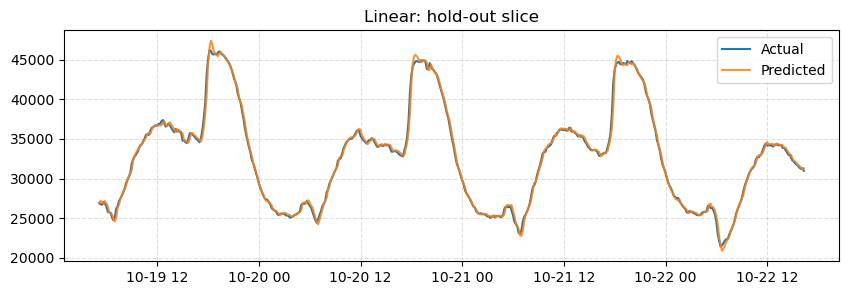

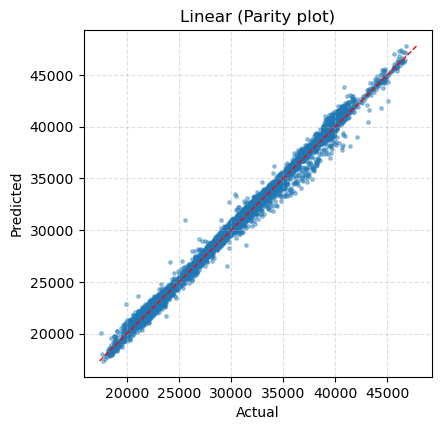

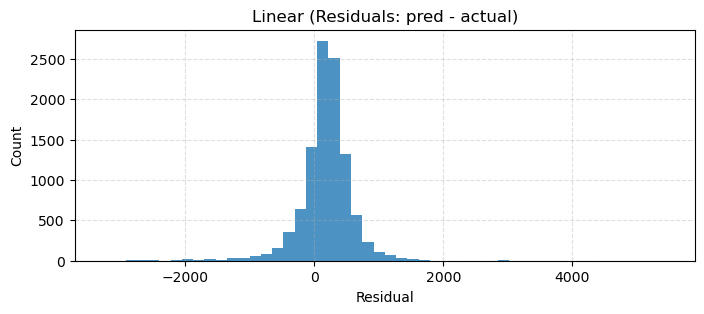

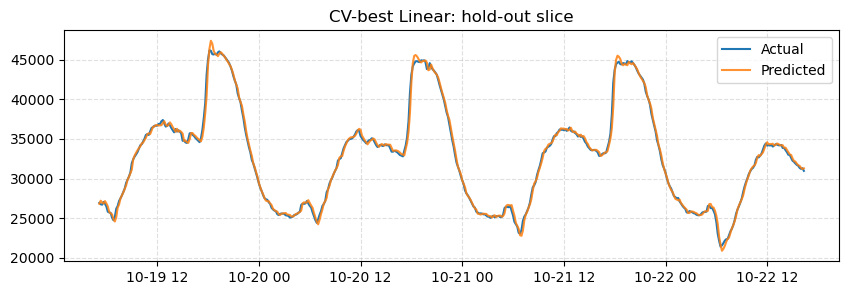

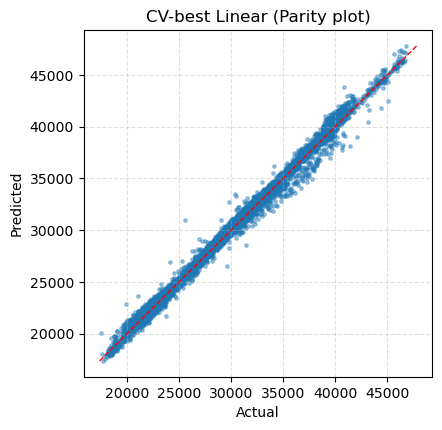

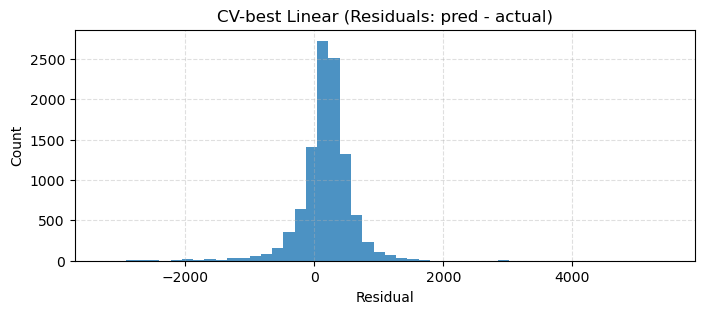

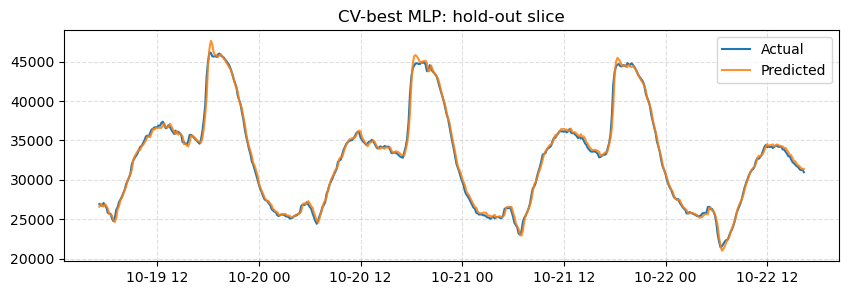

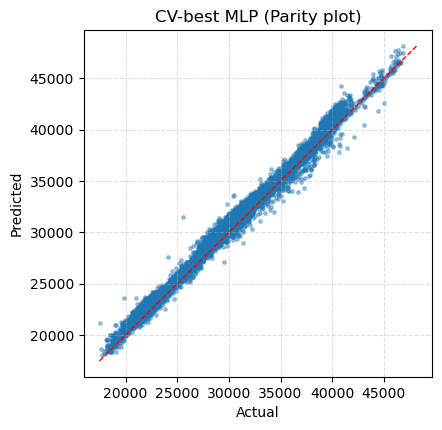

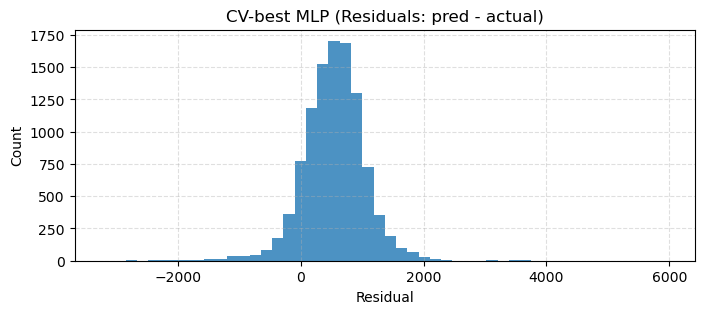

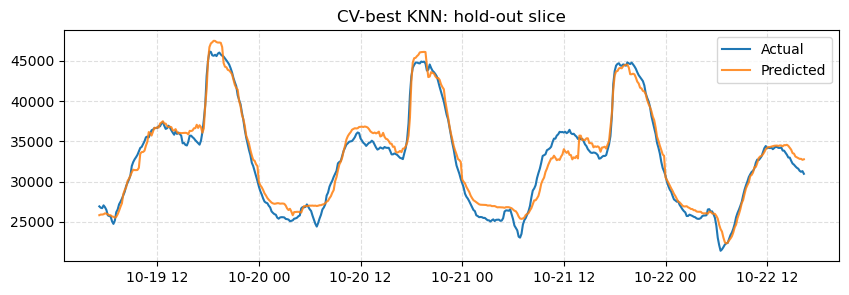

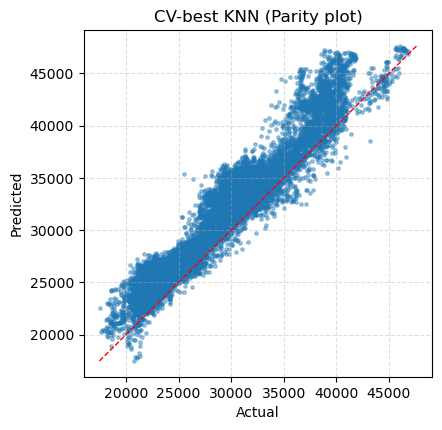

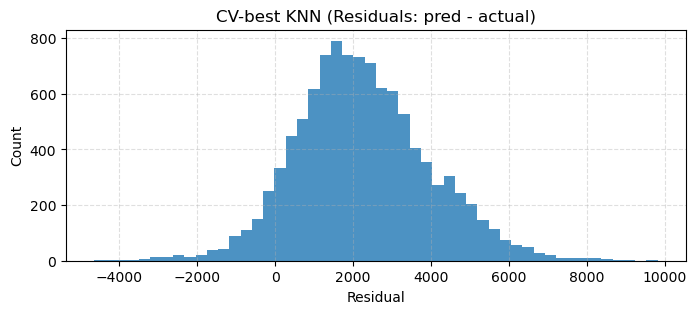

In [45]:
import matplotlib.pyplot as plt

def plot_time_series(y_true, y_pred, title, n=500):
    # Plot short validation slice; show fit quality over time
    idx = y_true.index[:min(n, len(y_true))]
    plt.figure(figsize=(10,3))
    plt.plot(idx, y_true.loc[idx], label="Actual")
    plt.plot(idx, pd.Series(y_pred, index=y_true.index).loc[idx], label="Predicted", alpha=0.85)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

def plot_parity(y_true, y_pred, title):
    # Plot predicted vs actual with y=x line; diagnose bias and dispersion
    yt = np.asarray(y_true)
    yp = np.asarray(y_pred)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    plt.figure(figsize=(4.5,4.5))
    plt.scatter(yt, yp, s=6, alpha=0.4)
    plt.plot(lims, lims, 'r--', linewidth=1)
    plt.title(title + " (Parity plot)")
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

def plot_residuals(y_true, y_pred, title):
    # Plot residual distribution to inspect skew/heavy tails; large tails inflate RMSE
    res = np.asarray(y_pred) - np.asarray(y_true)
    plt.figure(figsize=(8,3))
    plt.hist(res, bins=50, alpha=0.8)
    plt.title(title + " (Residuals: pred - actual)")
    plt.xlabel("Residual"); plt.ylabel("Count")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

# Choose a few representative models to visualize; adjust names to match your runs
viz_models = ["Linear", "CV-best Linear", "CV-best MLP", "CV-best KNN"]
for m in viz_models:
    y_hat = preds[m]
    plot_time_series(y_valid, y_hat, f"{m}: hold-out slice")
    plot_parity(y_valid, y_hat, f"{m}")
    plot_residuals(y_valid, y_hat, f"{m}")

### Compare CV vs hold-out
CV (within-train) vs Hold-out: CV estimates average performance on rolling splits inside the training window; hold-out tests on a later period that may have different regimes (e.g., holidays, weather shifts). Reasonable drift between CV and hold-out indicates dataset shift or model variance; large drift flags overfitting or missing features.

In [46]:
# Extract CV summaries from GridSearchCV; convert negative scoring to positive metrics
def cv_summary_frame(tag, search):
    # Identify the row picked by refit="MAE"; report both MAE and RMSE means across folds
    row = search.cv_results_["rank_test_MAE"].argmin()
    mae_cv  = -float(search.cv_results_["mean_test_MAE"][row])
    rmse_cv = -float(search.cv_results_["mean_test_RMSE"][row])
    return pd.DataFrame({"Model":[tag],"CV_MAE":[mae_cv],"CV_RMSE":[rmse_cv]})

cv_tab = pd.concat([
    cv_summary_frame("Linear", search_lin),
    cv_summary_frame("KNN",    search_knn),
    cv_summary_frame("MLP",    search_mlp),
], ignore_index=True)

# Add hold-out metrics for the exact best estimators
cv_tab["HO_MAE"]  = [
    compute_metrics(y_valid, search_lin.predict(X_valid))["MAE"],
    compute_metrics(y_valid, search_knn.predict(X_valid))["MAE"],
    compute_metrics(y_valid, search_mlp.predict(X_valid))["MAE"],
]
cv_tab["HO_RMSE"] = [
    compute_metrics(y_valid, search_lin.predict(X_valid))["RMSE"],
    compute_metrics(y_valid, search_knn.predict(X_valid))["RMSE"],
    compute_metrics(y_valid, search_mlp.predict(X_valid))["RMSE"],
]

print(cv_tab.round(3))

    Model    CV_MAE   CV_RMSE    HO_MAE   HO_RMSE
0  Linear   329.777   501.947   323.653   447.879
1     KNN  1360.255  1773.725  2368.026  2827.955
2     MLP   512.065   703.777   615.779   739.599


### Quick takeaways + what to try next
 * Linear baseline strong: Your CV Linear ~MAE≈330, RMSE≈502 looks solid; simple models often fare well on load with calendar + lags.
 * KNN underperforms: High-dimensional distances + temporal regime changes degrade neighbor quality; CV picked n_neighbors=21, p=1, which smooths but lags peaks.
 * MLP competitive: CV MAE≈512, RMSE≈704 suggests the net learns nonlinearity but may need more autoregressive context or regularization tuning.
 * Why earlier “RMSE” looked huge: Those were MSE values; after sqrt, hold-out RMSE should live near the CV scale (hundreds–low thousands, depending on your target units).

Improvements to consider for my future ref:
 * Add more lags (e.g., 18, 24, 72 ten-min steps ≈ 3h, 4h, 12h) to capture slower dynamics.
 * Add interactions (e.g., temperature × hour) to encode time-varying weather elasticity.
 * Try hour-ahead target (y = zone1_power.shift(-6)) for a realistic operational horizon.
 * Consider median absolute error (MdAE) to assess robustness to spiky days.
 * For KNN, consider dimension reduction (PCA on features) before the regressor to reduce distance concentration.